# Benchmark de numero de especies — PSA Zeolite 13X
Configuracion de referencia identica a `test_steps_psa` (L=1.35 m, Di=0.30 m, N=21).  
Se varia **nc = 2, 3, 4, 5, 6** especies:  
- CO2, CH4: adsorbentes (isotermas ajustadas desde CSV + Arrhenius)  
- N2, O2, H2, CO: no adsorbentes (q_eq = 0)  
Metricas: wall_time, balance de masa, perfiles axiales, series temporales.

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.utils.isotherm_fitting import fit_single_T
from src.utils.isotherm_models  import arrh

from src.units.adsorber.config.gas_props  import build_gas_prop_config
from src.units.adsorber.config.adsorbent  import build_adsorbent_config
from src.units.adsorber.config.transport  import build_transport_config
from src.units.adsorber.config.thermal_bc import build_thermal_bc_config
from src.units.adsorber.config.boundary_c import build_boundary_c_config
from src.units.adsorber.config.initial_c  import build_initial_c_config
from src.units.adsorber.state             import pack_state_vector

from src.solvers.runner_adsorption import run_step
from src.postprocessing.adsorber_balances   import balance_report

DB_PATH   = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
DATA_PATH = os.path.join(os.getcwd(), "data", "Zeolite13X.csv")

plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
print("Imports OK")
print("gasdb   :", os.path.isfile(DB_PATH))
print("CSV iso :", os.path.isfile(DATA_PATH))

Imports OK
gasdb   : True
CSV iso : True


In [2]:
df_iso = pd.read_csv(DATA_PATH)
P_CO2  = df_iso["Pressure_CO2 (bar)"].dropna().values
q_CO2  = df_iso["Uptake_CO2 (mol/kg)"].dropna().values
P_CH4  = df_iso["Pressure_CH4 (bar)"].dropna().values
q_CH4  = df_iso["Uptake_CH4 (mol/kg)"].dropna().values

T_REF  = 298.15    # K — referencia Arrhenius
dH_CO2 = 31.164e3  # J/mol
dH_CH4 =  9.856e3  # J/mol

iso_CO2_P, par_CO2, name_CO2, _ = fit_single_T(P_CO2, q_CO2)
iso_CH4_P, par_CH4, name_CH4, _ = fit_single_T(P_CH4, q_CH4)

def iso_CO2_PT(P_bar, T_K):
    return iso_CO2_P(np.asarray(P_bar) * arrh(float(T_K), dH_CO2, T_REF))

def iso_CH4_PT(P_bar, T_K):
    return iso_CH4_P(np.asarray(P_bar) * arrh(float(T_K), dH_CH4, T_REF))

def make_iso_fn(nc):
    """
    Devuelve iso_fn(P_part_list, Ts) -> ndarray(nc, N_loc).
    Indices 0,1 = CO2,CH4 (adsorbentes); 2..nc-1 = no adsorbentes (q=0).
    """
    def iso_fn(P_part_list, Ts):
        Ts_arr = np.asarray(Ts, dtype=float)
        N_loc  = len(Ts_arr)
        q_eq   = np.zeros((nc, N_loc), dtype=float)
        for n in range(N_loc):
            q_eq[0, n] = iso_CO2_PT(float(P_part_list[0][n]), Ts_arr[n])
            if nc >= 2:
                q_eq[1, n] = iso_CH4_PT(float(P_part_list[1][n]), Ts_arr[n])
            # indices 2..nc-1: no adsorbentes, q_eq ya es 0
        return q_eq
    return iso_fn

print(f"Isoterma CO2: {name_CO2}  |  CH4: {name_CH4}")


Isoterma CO2: Dual-site Langmuir  |  CH4: Dual-site Langmuir


In [3]:
# Pool de especies (orden fijo: CO2=0, CH4=1, N2=2, O2=3, H2=4, CO=5)
SPECIES_POOL = ["CO2", "CH4", "N2", "O2", "H2", "CO"]

# Geometria — identica a test_steps_psa
N      = 21
L      = 1.35
Di     = 0.30
Do     = 0.35
Ai     = 0.25 * np.pi * Di**2
Pi     = np.pi * Di
Po     = np.pi * Do
e_wall = (Do - Di) / 2.0
dz     = L / N

# Adsorbente Zeolite 13X — identico a test_steps_psa
epsi       = 0.37
D_particle = 12.0e-4
rho_s      = 3200.0
Cp_s       = 1200.0
k_s        = 10.0
tau_pore   = 3.0
r_pore     = 1.0e-9

# Condiciones de operacion
P_inlet  = 9.5
P_outlet = 9.0
T_feed   = 323.0
Cv_in    = 2.5e-1
Cv_out   = 1.5
Q_feed   = 0.05 * Ai   # m3/s

# Benchmark
NC_VALUES = [2, 3, 4, 5, 6]
T_MAX     = 60.0
N_SEC     = 20
RTOL      = 1.0e-8
ATOL      = 1.0e-10
SOLVER    = "solve_ivp"

print(f"Sistema : L={L} m  Di={Di} m  N={N}")
print(f"Operacion: P={P_inlet}/{P_outlet} bar  T={T_feed} K  T_MAX={T_MAX} s")
print(f"NC_VALUES={NC_VALUES}")


Sistema : L=1.35 m  Di=0.3 m  N=21
Operacion: P=9.5/9.0 bar  T=323.0 K  T_MAX=60.0 s
NC_VALUES=[2, 3, 4, 5, 6]


In [4]:
def build_params(nc):
    """
    Construye (params, sv0) para nc especies.

    - SPECIES_POOL[:nc] — CO2 y CH4 adsorbentes, resto no adsorbentes.
    - Feed equimolar: y_i = 1/nc para todas las especies.
    - Inicial: CO2 traza (0.01), resto distribuido equitativamente.
    - dH_adsorption = [dH_CO2, dH_CH4, 0, ..., 0][:nc].
    """
    species = SPECIES_POOL[:nc]
    iso_fn  = make_iso_fn(nc)
    dH_pool = [dH_CO2, dH_CH4, 0.0, 0.0, 0.0, 0.0]
    dH_ads  = np.array(dH_pool[:nc], dtype=float)

    # 1. Propiedades del gas
    prop_gas = build_gas_prop_config(
        species=species, mode="constant", n_comp=nc, N=N,
        T_ref=T_feed, db_path=DB_PATH,
    )
    gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))

    # 2. Adsorbente + isoterma
    ads = build_adsorbent_config(
        iso_fn=iso_fn, n_comp=nc, N=N,
        epsi=epsi, D_particle=D_particle,
        rho_s=rho_s, Cp_solid=Cp_s, k_solid=k_s,
        dH_adsorption=dH_ads, tau=tau_pore, r_pore=r_pore,
    )

    # 3. Transporte
    trans = build_transport_config(mode="correlation", n_comp=nc, N=N)

    # 4. Pared (ambient_htc)
    thermal_bc = build_thermal_bc_config(
        mode="ambient_htc", Di=Di, Do=Do, e_wall=e_wall,
        h_ambi=250.0, T_ambi=298.0, k_wall=2.0,
    )

    # 5. Condiciones de contorno
    y_feed = np.ones(nc) / nc   # equimolar
    bc = build_boundary_c_config(
        n_comp=nc, N=N, forward_flow_direction=True,
        Q_in_feed=Q_feed,  P_in_feed=P_inlet,  T_in_feed=T_feed,  y_in_feed=y_feed,
        P_out_ads=P_outlet, Cv_out_ads=Cv_out,
        Q_in_purge=Q_feed, P_in_purge=P_inlet, T_in_purge=T_feed, y_in_purge=y_feed,
        P_out_purge=P_outlet, Cv_out_purge=Cv_out,
        P_high=P_inlet, Cv_in_prfeed=Cv_in,
        P_low=1.0, Cv_out_blowdown=Cv_out, Cv_eq_lm=Cv_out, Cv_eq_mh=Cv_out,
    )

    # 6. Condiciones iniciales (CO2 traza, resto distribuido)
    y_CO2_0  = 0.01
    y_rest_0 = (1.0 - y_CO2_0) / max(nc - 1, 1)
    y_init_vec = np.array([y_CO2_0] + [y_rest_0] * max(nc - 1, 0))
    y_init = np.tile(y_init_vec.reshape(-1, 1), (1, N))   # (nc, N)
    P_init = P_inlet * np.ones(N)
    T_init = T_feed  * np.ones(N)

    ic = build_initial_c_config(
        P_init=P_init, Tg_init=T_init, Ts_init=T_init, y_init=y_init,
        n_comp=nc, N=N, iso_fn=ads["iso"],
        prop_gas=prop_gas, epsi=epsi, gas_T_ref=gas_T_ref, q_init=None,
    )
    sv0 = pack_state_vector(
        C=ic["C_init"], q=ic["q_init"],
        Hg=ic["Hg_init"], Ts=ic["Ts_init"],
    )

    params = {
        "n_comp": nc, "N": N, "dz": dz,
        "Ai": Ai, "Di": Di, "Pi": Pi, "Po": Po,
        "prop_gas":          prop_gas,
        "MW":                np.asarray(prop_gas["MW"]),
        "gas_T_ref":         gas_T_ref,
        "iso_fn":            ads["iso"],
        "epsi":              ads["epsi"],
        "rho_s":             ads["rho_s"],
        "Cp_s":              ads["Cp_s"],
        "k_s":               ads["k_s"],
        "dH":                ads["dH_comp"],
        "prop_lecho":        ads["prop_lecho"],
        "bc_config":         bc,
        "trans_config":      trans,
        "thermal_bc_config": thermal_bc,
        "prop_update_mode":  "frozen",
        "trans_update_mode": "frozen",
        "energy":            True,
        "Tg_init":           T_init.copy(),
        "species":           species,
        "_cache":            {},
    }
    return params, sv0

# Smoke test
p_test, sv_test = build_params(2)
print(f"build_params(2) OK | sv_size={sv_test.size}")


build_params(2) OK | sv_size=126


In [5]:
RESULTS = {}
n_total = len(NC_VALUES)

for idx, nc_val in enumerate(NC_VALUES):
    species_names = SPECIES_POOL[:nc_val]
    print(f"[{idx+1}/{n_total}] nc={nc_val}  {species_names}  ...", end=" ", flush=True)
    try:
        params, sv0 = build_params(nc_val)

        t0 = time.perf_counter()
        t_arr, y_hist, col = run_step(
            "ads", sv0, T_MAX, params,
            solver=SOLVER, rtol=RTOL, atol=ATOL,
            n_sec=N_SEC, show_progress=False,
        )
        wall_time = time.perf_counter() - t0

        df_bal = balance_report(col, params, include_energy=False, print_report=False)

        def _get(df, row):
            try: return float(df.loc[row, "Error rel [%]"])
            except: return float("nan")

        err_total = abs(_get(df_bal, "N_total [mol]"))
        err_co2   = abs(_get(df_bal, "N_CO2 [mol]"))
        err_ch4   = abs(_get(df_bal, "N_CH4 [mol]"))

        RESULTS[nc_val] = {
            "nc": nc_val, "species": species_names,
            "sv_size": sv0.size, "col": col, "t_arr": t_arr,
            "wall_time": wall_time,
            "err_total": err_total, "err_co2": err_co2, "err_ch4": err_ch4,
            "ok": True,
        }
        print(f"t={wall_time:.2f}s  |  err_total={err_total:.3f}%  "
              f"CO2={err_co2:.3f}%  CH4={err_ch4:.3f}%")

    except Exception as exc:
        RESULTS[nc_val] = {"ok": False, "error": str(exc)}
        print(f"FAILED: {str(exc)[:80]}")

print("\nBucle completado.")


[1/5] nc=2  ['CO2', 'CH4']  ... t=26.41s  |  err_total=0.000%  CO2=0.000%  CH4=0.000%
[2/5] nc=3  ['CO2', 'CH4', 'N2']  ... t=18.72s  |  err_total=0.001%  CO2=0.000%  CH4=0.004%
[3/5] nc=4  ['CO2', 'CH4', 'N2', 'O2']  ... t=18.37s  |  err_total=0.001%  CO2=0.000%  CH4=0.012%
[4/5] nc=5  ['CO2', 'CH4', 'N2', 'O2', 'H2']  ... t=21.19s  |  err_total=0.001%  CO2=0.000%  CH4=0.012%
[5/5] nc=6  ['CO2', 'CH4', 'N2', 'O2', 'H2', 'CO']  ... t=22.39s  |  err_total=0.001%  CO2=0.000%  CH4=0.026%

Bucle completado.


## Dashboard A — Coste computacional y balance de masa vs nc

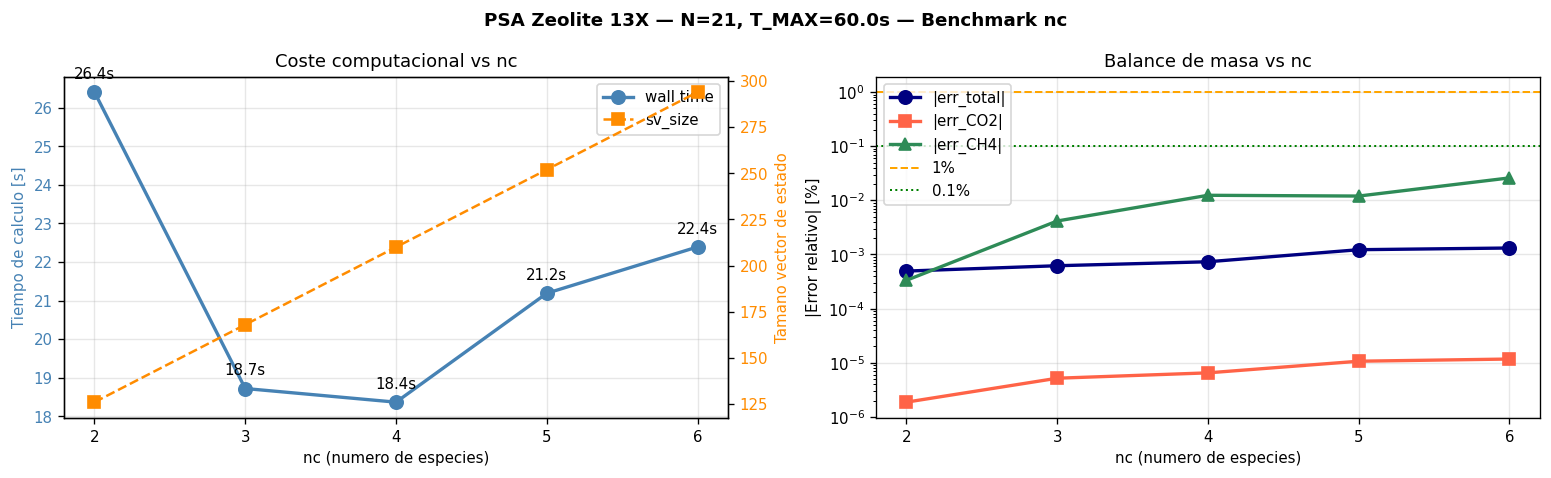

In [6]:
ncv = [nc for nc in NC_VALUES if RESULTS[nc].get("ok")]
wt  = [RESULTS[nc]["wall_time"] for nc in ncv]
sv  = [RESULTS[nc]["sv_size"]   for nc in ncv]
et  = [RESULTS[nc]["err_total"] for nc in ncv]
eco2= [RESULTS[nc]["err_co2"]   for nc in ncv]
ech4= [RESULTS[nc]["err_ch4"]   for nc in ncv]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"PSA Zeolite 13X — N={N}, T_MAX={T_MAX}s — Benchmark nc",
             fontsize=11, fontweight="bold")

# Tiempo de calculo
ax1.plot(ncv, wt, "o-", color="steelblue", lw=2, ms=8, label="wall time")
for nc_v, wt_v in zip(ncv, wt):
    ax1.annotate(f"{wt_v:.1f}s", (nc_v, wt_v), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=9)
ax1r = ax1.twinx()
ax1r.plot(ncv, sv, "s--", color="darkorange", lw=1.5, ms=7, label="sv_size")
ax1r.set_ylabel("Tamano vector de estado", color="darkorange")
ax1r.tick_params(axis="y", labelcolor="darkorange")
ax1.set_xlabel("nc (numero de especies)")
ax1.set_ylabel("Tiempo de calculo [s]", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_title("Coste computacional vs nc")
ax1.set_xticks(ncv)
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax1r.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, fontsize=9)
ax1.grid(True, alpha=0.3)

# Balance de masa
ax2.semilogy(ncv, et,   "o-", color="navy",     lw=2, ms=8, label="|err_total|")
ax2.semilogy(ncv, eco2, "s-", color="tomato",   lw=2, ms=7, label="|err_CO2|")
ax2.semilogy(ncv, ech4, "^-", color="seagreen", lw=2, ms=7, label="|err_CH4|")
ax2.axhline(1.0, ls="--", color="orange", lw=1.2, label="1%")
ax2.axhline(0.1, ls=":",  color="green",  lw=1.2, label="0.1%")
ax2.set_xlabel("nc (numero de especies)")
ax2.set_ylabel("|Error relativo| [%]")
ax2.set_title("Balance de masa vs nc")
ax2.set_xticks(ncv)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Dashboard B — Perfiles axiales a t = T_MAX

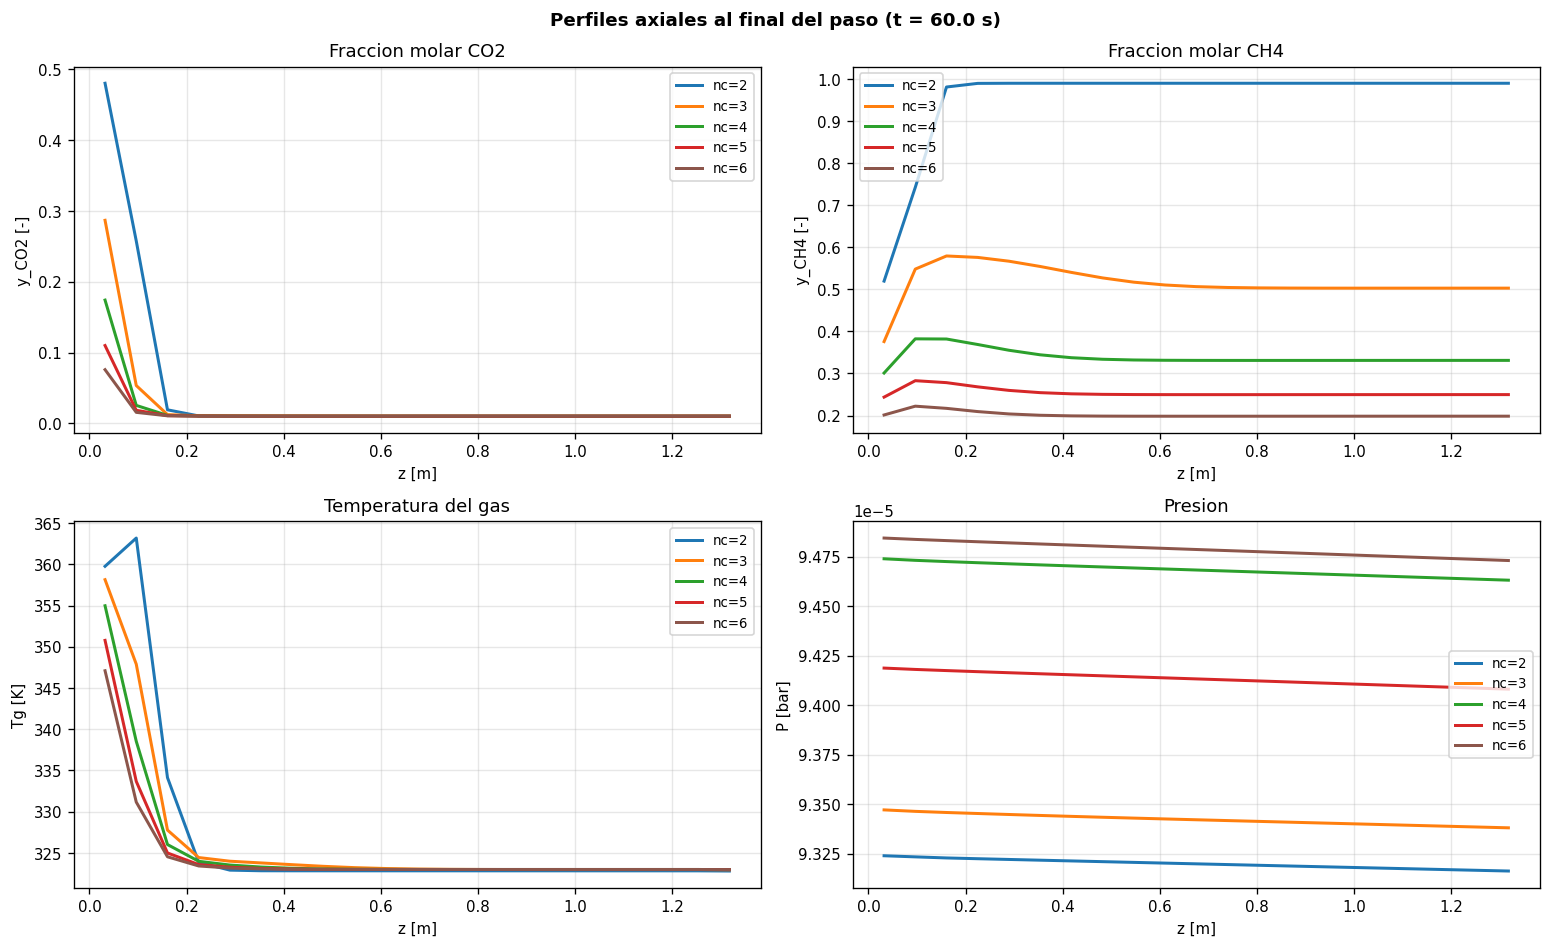

In [7]:
colors = cm.tab10(np.linspace(0, 0.5, len(ncv)))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f"Perfiles axiales al final del paso (t = {T_MAX} s)",
             fontsize=11, fontweight="bold")

vars_info = [
    ("_y_results",  0,    "y_CO2 [-]",  "Fraccion molar CO2"),
    ("_y_results",  1,    "y_CH4 [-]",  "Fraccion molar CH4"),
    ("_Tg_results", None, "Tg [K]",     "Temperatura del gas"),
    ("_P_results",  None, "P [bar]",    "Presion"),
]

for ax, (attr, comp, ylabel, title) in zip(axes.flat, vars_info):
    for color, nc_v in zip(colors, ncv):
        col = RESULTS[nc_v]["col"]
        z   = col._z
        data = getattr(col, attr)
        if comp is not None:
            y_data = data[-1, comp, :]
        else:
            y_data = data[-1, :]
            if attr == "_P_results":
                y_data = y_data / 1e5   # Pa -> bar
        ax.plot(z, y_data, color=color, lw=1.8, label=f"nc={nc_v}")
    ax.set_xlabel("z [m]"); ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Dashboard C — Series temporales en la salida (z = L)

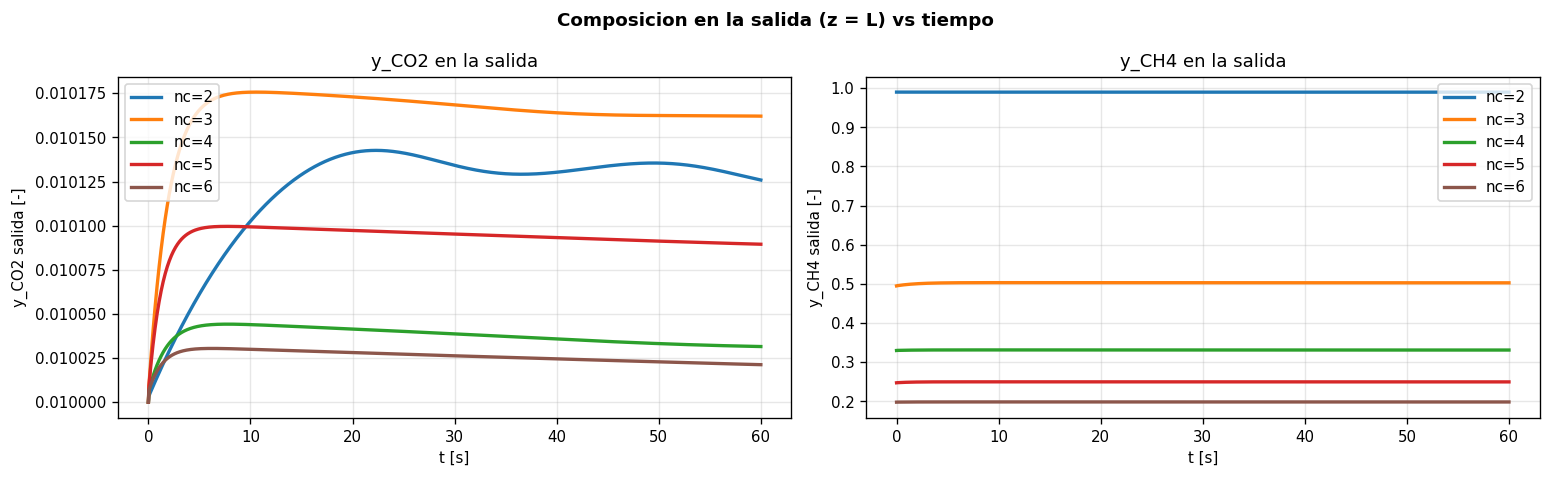

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Composicion en la salida (z = L) vs tiempo",
             fontsize=11, fontweight="bold")

for color, nc_v in zip(colors, ncv):
    col   = RESULTS[nc_v]["col"]
    t_arr = RESULTS[nc_v]["t_arr"]
    ax1.plot(t_arr, col._y_results[:, 0, -1], color=color, lw=2, label=f"nc={nc_v}")
    ax2.plot(t_arr, col._y_results[:, 1, -1], color=color, lw=2, label=f"nc={nc_v}")

ax1.set_xlabel("t [s]"); ax1.set_ylabel("y_CO2 salida [-]")
ax1.set_title("y_CO2 en la salida"); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax2.set_xlabel("t [s]"); ax2.set_ylabel("y_CH4 salida [-]")
ax2.set_title("y_CH4 en la salida"); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Tabla resumen

In [9]:
def quality(err):
    if err < 0.1:  return "EXCELENTE"
    if err < 0.5:  return "BUENO"
    if err < 1.0:  return "ACEPTABLE"
    return "REVISAR"

rows = []
for nc_v in NC_VALUES:
    r = RESULTS.get(nc_v, {})
    if not r.get("ok"):
        rows.append({"nc": nc_v, "especies": str(SPECIES_POOL[:nc_v]),
                     "sv_size": "-", "wall_t [s]": "-",
                     "err_total%": "-", "err_CO2%": "-", "err_CH4%": "-",
                     "calidad": "ERROR"})
        continue
    rows.append({
        "nc":         nc_v,
        "especies":   " | ".join(r["species"]),
        "sv_size":    r["sv_size"],
        "wall_t [s]": f"{r['wall_time']:.1f}",
        "err_total%": f"{r['err_total']:.4f}",
        "err_CO2%":   f"{r['err_co2']:.4f}",
        "err_CH4%":   f"{r['err_ch4']:.4f}",
        "calidad":    quality(r["err_total"]),
    })

df_res = pd.DataFrame(rows).set_index("nc")

def color_calidad(val):
    m = {"EXCELENTE": "background-color:#c6efce;color:#276221",
         "BUENO":     "background-color:#e2efda;color:#375623",
         "ACEPTABLE": "background-color:#ffeb9c;color:#9c6500",
         "REVISAR":   "background-color:#ffc7ce;color:#9c0006",
         "ERROR":     "background-color:#f4cccc;color:#cc0000"}
    return m.get(val, "")

styled = (
    df_res.style
    .applymap(color_calidad, subset=["calidad"])
    .set_caption(f"Benchmark nc — N={N}, T_MAX={T_MAX}s, RTOL={RTOL}, ATOL={ATOL}")
)
display(styled)


,especies,sv_size,wall_t [s],err_total%,err_CO2%,err_CH4%,calidad
nc,,,,,,,
2,CO2 | CH4,126,26.4,0.0005,0.0000,0.0003,EXCELENTE
3,CO2 | CH4 | N2,168,18.7,0.0006,0.0000,0.0041,EXCELENTE
4,CO2 | CH4 | N2 | O2,210,18.4,0.0007,0.0000,0.0124,EXCELENTE
5,CO2 | CH4 | N2 | O2 | H2,252,21.2,0.0012,0.0000,0.0120,EXCELENTE
6,CO2 | CH4 | N2 | O2 | H2 | CO,294,22.4,0.0013,0.0000,0.0260,EXCELENTE


## Analisis de escala

In [10]:
t_base  = RESULTS[2]["wall_time"] if RESULTS.get(2, {}).get("ok") else 1.0
sv_base = RESULTS[2]["sv_size"]   if RESULTS.get(2, {}).get("ok") else 1

print(f"{'nc':>4}  {'sv_size':>8}  {'sv x base':>10}  "
      f"{'wall_t [s]':>12}  {'t x base':>10}")
print("-" * 54)
for nc_v in ncv:
    r = RESULTS[nc_v]
    print(f"{nc_v:>4}  {r['sv_size']:>8}  {r['sv_size']/sv_base:>10.2f}  "
          f"{r['wall_time']:>12.2f}  {r['wall_time']/t_base:>10.2f}")

print()
print("sv_size = N * (2*nc + 2):")
for nc_v in ncv:
    print(f"  nc={nc_v}  sv_size = {N}*{2*nc_v+2} = {N*(2*nc_v+2)}")


  nc   sv_size   sv x base    wall_t [s]    t x base
------------------------------------------------------
   2       126        1.00         26.41        1.00
   3       168        1.33         18.72        0.71
   4       210        1.67         18.37        0.70
   5       252        2.00         21.19        0.80
   6       294        2.33         22.39        0.85

sv_size = N * (2*nc + 2):
  nc=2  sv_size = 21*6 = 126
  nc=3  sv_size = 21*8 = 168
  nc=4  sv_size = 21*10 = 210
  nc=5  sv_size = 21*12 = 252
  nc=6  sv_size = 21*14 = 294
